# Исследовательский анализ рынка общественного питания Москвы

### Цели и задачи проекта

#### Цель 
- на основе предоставлнных данных предоставить заказчику рекомендации для открытия заведения общественного питания в Москве

#### Задачи
- ознакомиться с предоставленными данными 
- провести их предобработку
- провести исследовательский анализ, выявить закономерности
- исходя из выявленных законорностей, сформулировать рекомендации для заказчика 


### Описание данных

Предоставлен датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер.


Файл **/datasets/rest_info.csv** содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- seats — количество посадочных мест.


Файл **/datasets/rest_price.csv** содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    «Средний счёт: 1000–1500 ₽»;
    «Цена чашки капучино: 130–220 ₽»;
    «Цена бокала пива: 400–600 ₽».
    и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


### Содержимое проекта

1. Загрузка данных и знакомство с ними    
   
2. Предобработка данных

3. Исследовательский анализ данных

4. Итоговый вывод и рекомендации

---

## 1. Загрузка данных и знакомство с ними

In [86]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from phik import phik_matrix


In [87]:
df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')

In [88]:
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


#### Анализ:

- датафрейм содержит 8406 строк, 9 столбцов
- пропуски есть в столбцых hours, seats
- В типах данных есть неточность для seats (может быть только натуральным числом), для корректности надо перевести от float к int
- после перевода seats к int можно понизить размерность
- chain можно перевести в bool, поскольку это признак (значения только 0, 1)

In [89]:
# явные пропуски в данных
df_info.isna().sum() / len(df_info) * 100

id           0.000000
name         0.000000
category     0.000000
address      0.000000
district     0.000000
hours        6.376398
rating       0.000000
chain        0.000000
seats       42.957411
dtype: float64

In [90]:
# проверка остальных столбцов
df_info['id'].nunique()  # все id уникальны

8406

In [91]:
# визуальная проверка на пропуски-флаги
df_info['category'].unique()

<StringArray>
[           'кафе',        'ресторан',         'кофейня',        'пиццерия',
         'бар,паб', 'быстрое питание',        'булочная',        'столовая']
Length: 8, dtype: str

In [92]:
df_info['district'].unique()

<StringArray>
[        'Северный административный округ',
 'Северо-Восточный административный округ',
  'Северо-Западный административный округ',
         'Западный административный округ',
      'Центральный административный округ',
        'Восточный административный округ',
    'Юго-Восточный административный округ',
            'Южный административный округ',
     'Юго-Западный административный округ']
Length: 9, dtype: str

In [93]:
df_info['rating'].unique()

array([5. , 4.5, 4.6, 4.4, 4.7, 4.8, 4.3, 4.9, 4.2, 4.1, 4. , 3.8, 3.9,
       3.7, 3.6, 2.8, 2.7, 3.1, 1.5, 2. , 1.4, 3.3, 3.5, 3.2, 2.9, 3. ,
       3.4, 2.3, 2.2, 2.5, 2.6, 1.7, 1. , 1.1, 2.4, 1.3, 1.2, 2.1, 1.8,
       1.9, 1.6])

In [94]:
df_info['address'].unique()

<StringArray>
[                                       'Москва, улица Дыбенко, 7/1',
                                'Москва, улица Дыбенко, 36, корп. 1',
                                    'Москва, Клязьминская улица, 15',
                               'Москва, улица Маршала Федоренко, 12',
                                   'Москва, Правобережная улица, 1Б',
                                      'Москва, Ижорская улица, вл8Б',
                             'Москва, Клязьминская улица, 9, стр. 3',
                           'Москва, Дмитровское шоссе, 107, корп. 4',
                                       'Москва, Ангарская улица, 39',
                                    'Москва, Левобережная улица, 12',
 ...
                                    'Москва, Ташкентская улица, 29А',
                              'Москва, улица Михайлова, 22, корп. 4',
                              'Москва, Большая Косинская улица, 24А',
                              'Москва, 1-я Новокузьминская улица, 3',
 

In [95]:
df_info['chain'].unique()

array([0, 1])

In [96]:
df_info['seats'].unique()

array([      nan, 4.000e+00, 4.500e+01, 1.480e+02, 7.900e+01, 6.500e+01,
       1.020e+02, 1.800e+02, 9.600e+01, 2.500e+01, 4.600e+01, 4.000e+01,
       2.470e+02, 2.100e+01, 8.000e+00, 3.500e+01, 2.400e+02, 8.500e+01,
       1.200e+01, 6.000e+01, 1.200e+02, 1.600e+01, 8.000e+01, 5.000e+01,
       4.400e+01, 4.300e+01, 9.000e+01, 0.000e+00, 1.980e+02, 9.500e+01,
       3.500e+02, 1.240e+02, 1.000e+01, 7.000e+01, 4.800e+01, 6.000e+00,
       9.800e+01, 3.000e+01, 5.200e+01, 2.000e+01, 2.000e+00, 1.800e+01,
       2.200e+01, 1.500e+01, 2.800e+01, 3.000e+02, 7.500e+01, 3.200e+01,
       1.000e+02, 1.100e+02, 2.300e+02, 2.500e+02, 1.300e+02, 8.400e+01,
       3.980e+02, 2.700e+01, 2.860e+02, 1.450e+02, 3.600e+01, 9.700e+01,
       2.260e+02, 1.400e+02, 1.660e+02, 2.020e+02, 9.400e+01, 1.890e+02,
       5.300e+01, 1.040e+02, 7.200e+01, 1.310e+02, 1.050e+02, 5.500e+01,
       1.700e+01, 1.000e+00, 1.150e+02, 3.100e+02, 7.700e+01, 1.600e+02,
       3.200e+02, 3.400e+01, 1.500e+02, 2.000e+02, 

на первый взгляд неявных пропусков нет

In [97]:
# смотрим на дубликаты
df_info.duplicated().sum()
# явных дубликатов нет

np.int64(0)

In [98]:
df_info.duplicated(subset='id').sum()  # все id уникальны, неявных дубликатов нет

np.int64(0)

#### Промежуточный итог для rest_info.csv:

- датафрейм содержит 8406 строк, 9 столбцов
- В типах данных есть неточность для seats (может быть только натуральным числом), для корректности надо перевести от float к int
- после перевода seats к int можно понизить размерность
- chain можно привести к bool (значения только 0, 1)
- явные пропуски: seats - 43% пропусков, hours - 6.4% пропусков. Пропусков слишком много, чтобы их удалять. Необходимо проводить анализ.
- на первый взгляд индикаторов-пропусков нет
- явных и неявных дубликатов нет

In [99]:
df_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [100]:
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [101]:
df_price.info()
# 4058 строк, 5 колонок
# пропуски в price, avg_bill, middle_avg_bill, middle_coffee_cup

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 158.6 KB


In [102]:
# явные пропуски
df_price.isna().sum() / df_price.shape[0] * 100

id                    0.000000
price                18.309512
avg_bill              5.963529
middle_avg_bill      22.400197
middle_coffee_cup    86.816166
dtype: float64

In [103]:
# неявные пропуски
df_price['price'].unique()

<StringArray>
['выше среднего', 'средние', nan, 'высокие', 'низкие']
Length: 5, dtype: str

In [104]:
df_price['avg_bill'].unique()

<StringArray>
[     'Средний счёт:1500–1600 ₽',        'Средний счёт:от 1000 ₽',
 'Цена чашки капучино:155–185 ₽',        'Средний счёт:400–600 ₽',
                             nan,            'Средний счёт:199 ₽',
        'Средний счёт:200–300 ₽',         'Средний счёт:от 500 ₽',
      'Средний счёт:1000–1200 ₽',    'Цена бокала пива:250–350 ₽',
 ...
  'Цена чашки капучино:80–240 ₽',       'Средний счёт:300–1600 ₽',
         'Средний счёт:70–200 ₽', 'Цена чашки капучино:160–230 ₽',
       'Средний счёт:180–1170 ₽',    'Цена бокала пива:160–390 ₽',
        'Средний счёт:120–130 ₽', 'Цена чашки капучино:120–220 ₽',
 'Цена чашки капучино:100–220 ₽',  'Цена чашки капучино:80–120 ₽']
Length: 898, dtype: str

In [105]:
df_price['middle_avg_bill'].unique()

array([1.550e+03, 1.000e+03,       nan, 5.000e+02, 1.990e+02, 2.500e+02,
       1.100e+03, 3.300e+02, 1.500e+03, 4.000e+02, 2.450e+02, 4.250e+02,
       9.000e+02, 2.400e+02, 2.250e+02, 3.280e+02, 3.000e+02, 3.450e+02,
       2.300e+02, 6.500e+02, 7.500e+02, 1.250e+03, 1.750e+03, 2.250e+03,
       6.000e+02, 4.500e+02, 8.500e+02, 2.100e+03, 3.490e+02, 2.000e+02,
       1.200e+02, 2.690e+02, 1.300e+03, 1.150e+03, 3.550e+02, 2.750e+02,
       1.200e+03, 5.750e+02, 3.500e+02, 7.000e+02, 2.840e+02, 1.500e+02,
       3.620e+02, 3.250e+02, 2.000e+03, 2.910e+02, 2.800e+02, 2.750e+03,
       1.400e+03, 2.500e+03, 2.150e+03, 5.000e+03, 8.250e+02, 6.250e+02,
       3.250e+03, 6.750e+02, 4.750e+02, 1.690e+03, 9.250e+02, 1.050e+03,
       3.400e+02, 9.500e+02, 1.025e+03, 3.210e+02, 5.500e+02, 3.600e+02,
       3.750e+02, 3.170e+02, 3.240e+02, 3.430e+02, 1.400e+02, 1.650e+02,
       2.150e+02, 5.490e+02, 1.750e+02, 3.130e+02, 1.375e+03, 1.000e+02,
       9.750e+02, 1.100e+04, 8.000e+02, 2.950e+02, 

In [106]:
df_price['middle_coffee_cup'].unique()

array([  nan,  170.,  145.,  150.,  180.,  120.,  100.,  256.,  160.,
        250.,  165.,  149.,  135.,  220.,  175.,  195.,   60.,  214.,
         75.,   89.,   95.,  204.,   90.,  140.,  125.,  162.,  155.,
        154.,  297.,  205.,  124.,  200.,  190.,  134.,  139.,  287.,
        225.,  230.,  237.,  290.,  254.,  279.,  174.,  179.,  295.,
        245.,  105.,  285.,  270.,   84.,  127.,   80.,  112.,  185.,
        210.,  325.,  159.,  215.,  110.,  266.,  242.,  137.,  255.,
        240.,  217.,  315.,  130.,  167.,  169.,  235., 1568.,   79.,
        260.,  300.,  291.,  275.,  115.,  328.,   94.,  265.,  184.,
        229.,  164.,  172.,  259.,  246.,  199.,  138.,  375.,  189.,
        320.,  197.,  227.,  102.,  119.,  144.,  129.])

на первый взгляд неявных пропусков нет

In [107]:
# явные Дубликаты 
df_price.duplicated().sum()

np.int64(0)

In [108]:
df_price.duplicated(subset='id').sum()  # все id уникальны, неявных дубликатов нет

np.int64(0)

#### Промежуточный итог для rest_price.csv:

- датафрейм содержит 4058 строк, 5 колонок
- в типах данных ошибок нет
- пропуски в price: 18.3%, avg_bill: 5.96%, middle_avg_bill: 22.4%, middle_coffee_cup: 86.8%. Пропусков много, необходимо проводить анализ, с чем они связаны.
- визуально неявных пропусков нет (значений-флагов)
- явных и неявных дубликатов в данных нет


---

### Промежуточный вывод


Объем данных:
- rest_info содержит 8406 строк, 9 столбцов
- rest_price содержит 4058 строк, 5 столбцов

Соответствие описанию:
- данные соответствуют описанию

Пропуски:
- явные пропуски rest_info: seats - 43% пропусков, hours - 6.4% пропусков. Пропусков слишком много, чтобы их удалять. Необходимо проводить анализ.
- явные пропуски rest_price: price - 18.3%, avg_bill - 5.96%, middle_avg_bill - 22.4%, middle_coffee_cup - 86.8%. Пропусков много, необходимо проводить анализ, с чем они связаны.
- на первый взгляд индикаторов-пропусков нет

Дубликаты:
- явных и неявных дубликатов нет

Типы данных:
- для rest_price ошибок нет
- для rest_info необходимо внести коррективы по типам + оптимизировать размерность 
    - В типах данных есть неточность для seats (может быть только натуральным числом), для корректности надо перевести от float к int
    - после перевода seats к int можно понизить размерность
    - для столбца chain можно провести оптимизацию с понижением размерности (значения только 0, 1)

### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [109]:
df = df_info.merge(df_price, on='id', how='left') # объединяем по id 

## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [110]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


Преобразование типов:
- chain переводим к bool (по смыслу это признак сетевой/не сетевой, значения [0, 1])
- seats (кол-во посадочных мест) - переведем в float с понижением размерности данных 
- rating от 0 до 5.0 - можно понизить размерность 
- для middle_avg_bill и middle_coffee_cup также можно понизить размерность

In [112]:
df['chain'] = df['chain'].astype(bool)
df['chain']

0       False
1       False
2       False
3       False
4        True
        ...  
8401    False
8402    False
8403    False
8404     True
8405    False
Name: chain, Length: 8406, dtype: bool

In [113]:
def float_downcast(col_name: str):
    return pd.to_numeric(df[col_name], downcast='float')

In [114]:
col_to_float_downcast = ['rating', 'middle_avg_bill', 'middle_coffee_cup', 'seats']

for col in col_to_float_downcast:
    df[col] = float_downcast(col)

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   bool   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: bool(1), float32(4), str(8)
memory usage: 665.1 KB


### Изучение и обработка пропусков

In [116]:
df.isna().sum() / df.shape[0] * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Анализ:

- seats, hours, price, avg_bill, middle_coffee_cup, middle_avg_bill - пропусков существенное количество. Удалять не будем. Оставим их как есть
- при обработке никакие данные не удалялись, она прошла без потерь


### Обработка дубликатов

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   bool   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: bool(1), float32(4), str(8)
memory usage: 665.1 KB


In [118]:
df.duplicated().sum() # явных дублей нет 

np.int64(0)

In [119]:
df['id'].nunique() # неявных дублей по id нет

8406

In [120]:
def to_snake_case(value):
    """Преобразует одно значение в snake_case."""
    if pd.isna(value):
        return value
    s = str(value).strip().lower()
    s = re.sub(r"[^\w\s-]", "", s, flags=re.UNICODE)  
    s = re.sub(r"[\s\-]+", "_", s)                  
    s = re.sub(r"_+", "_", s).strip("_") 
    return s

def normalize_columns_snake_case(df, columns):
    """Нормализует указанные столбцы DataFrame в snake_case."""
    df = df.copy()
    for col in columns:
        df[col] = df[col].apply(to_snake_case)
    return df

In [121]:
df = normalize_columns_snake_case(df, ["name", "address", 'district'])


In [122]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва_улица_дыбенко_71,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре_комнаты,ресторан,москва_улица_дыбенко_36_корп_1,северный_административный_округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва_клязьминская_улица_15,северный_административный_округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse_coffee_shop,кофейня,москва_улица_маршала_федоренко_12,северный_административный_округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль_марко,пиццерия,москва_правобережная_улица_1б,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [123]:
# копия данных
tmp = df.copy()

In [124]:
len(df[df.duplicated(subset=['name', 'address'], keep="first")]) / len(df) # есть дубли по адресу и имени


0.0005948132286462051

In [125]:
# дублей мало: менее 0.06%
# Можно спокойно удалить
df = df[~df.duplicated(subset=['name', 'address'], keep="first")]

In [126]:
print('Потеря при обработке дублей: ', (len(tmp) - len(df)) / len(tmp) * 100, '%')

Потеря при обработке дублей:  0.05948132286462051 %


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [127]:
df['hours'].unique()

<StringArray>
[                              'ежедневно, 10:00–22:00',
 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
                               'ежедневно, 09:00–22:00',
                               'ежедневно, 10:00–23:00',
                    'пн 15:00–04:00; вт-вс 15:00–05:00',
 'пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00',
                               'ежедневно, 12:00–00:00',
                             'ежедневно, круглосуточно',
                               'ежедневно, 10:00–21:00',
                                    'вт-сб 09:00–18:00',
 ...
    'пн-пт 09:00–23:00; сб 12:00–23:00; вс 10:00–23:00',
                               'ежедневно, 09:00–01:30',
                 'пн-пт 08:00–00:00; сб,вс 13:00–01:00',
                 'пн-пт 11:00–22:00; сб,вс 10:00–23:00',
                 'пн-пт 11:00–03:00; сб,вс 11:00–06:00',
    'пн 00:00–21:00; вт-сб 09:00–21:00; вс 00:00–21:00',
                 'пн-пт 07:00–20:00; сб,вс 09:00–19:00',
            

In [128]:
df['is_24_7'] = df['hours'].eq('ежедневно, круглосуточно')

In [129]:
# проверка на корректность разбиения
df['is_24_7'].value_counts()

is_24_7
False    7671
True      730
Name: count, dtype: int64

In [130]:
len(df[df['hours'] == 'ежедневно, круглосуточно'])

730

In [131]:
len(df[~(df['hours'] == 'ежедневно, круглосуточно')])

7671

разбиение корректно

---

### Промежуточный вывод


Исходное количество данных:
- Потерь при обработке пропусков нет
- проведена нормализация строковых данных для столбцов name, address, district
- проведен анализ дубликатов: явных дублей не выявлено, есть неявные дубли по name и address
- потеря при обработке неявных дублей менее 0.06%
- добавлен столбец is_24_7 с признаком круглосуточное заведение или нет

## 3. Исследовательский анализ данных

---

### Исследование количества объектов общественного питания по каждой категории.

In [132]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва_улица_дыбенко_71,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре_комнаты,ресторан,москва_улица_дыбенко_36_корп_1,северный_административный_округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва_клязьминская_улица_15,северный_административный_округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse_coffee_shop,кофейня,москва_улица_маршала_федоренко_12,северный_административный_округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль_марко,пиццерия,москва_правобережная_улица_1б,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


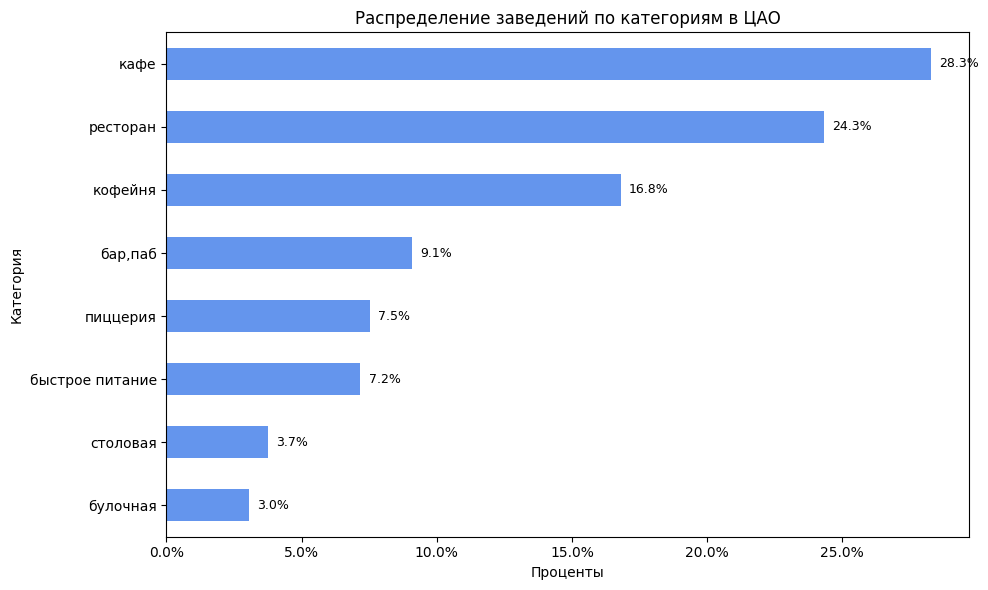

In [133]:
share = df['category'].value_counts(normalize=True).sort_values()



ax = share.plot(
    kind='barh', figsize=(10, 6), color='cornflowerblue'
)

ax.set_ylabel('Категория')          
ax.set_xlabel('Проценты')   
ax.set_title('Распределение заведений по категориям в ЦАО')

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

for i, v in enumerate(share.values):
    ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Анализ:
- в данных преимущественно преставлены кафе: 28.3%, рестораны: 24.3%
- кофеен 16.8%
- баров,пабов и пиццерий и быстрого питания  7-9% по каждой
- самые малочисленные группы: столовые, булочные - менее 4% по каждой

---

### Исследование распределения количества заведений по административным районам Москвы.

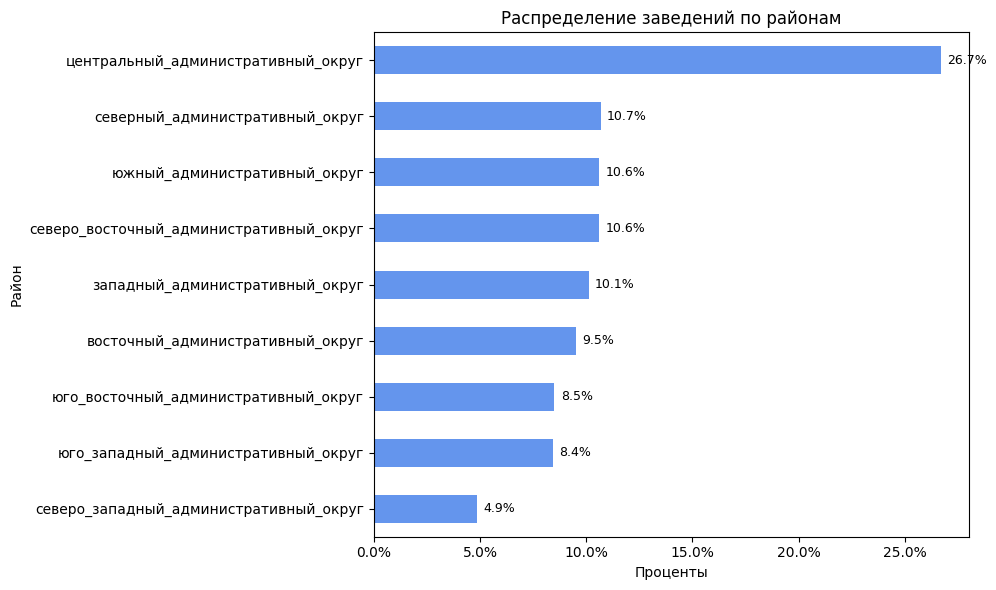

In [134]:
# Распределение по районам
district_share = df['district'].value_counts(normalize=True).sort_values()

ax = district_share.plot(
    kind='barh', figsize=(10, 6), color='cornflowerblue'
)

ax.set_ylabel('Район')          
ax.set_xlabel('Проценты')   
ax.set_title('Распределение заведений по районам')

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

for i, v in enumerate(district_share.values):
    ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Анализ:
- заведений из центрального округа около 26.7%, что существенно больше, чем из остальных округов 
- в для 78% округов доля составляет от 8% до 11% 
- меньше всего заведений в северо-западном округе - 4.9%
- такое распределение по количеству заведений говорит о том, что в центре выше спрос на заведения общественного питания. Как следствие, там больше и предложение, больше потенциальных конкурентов.

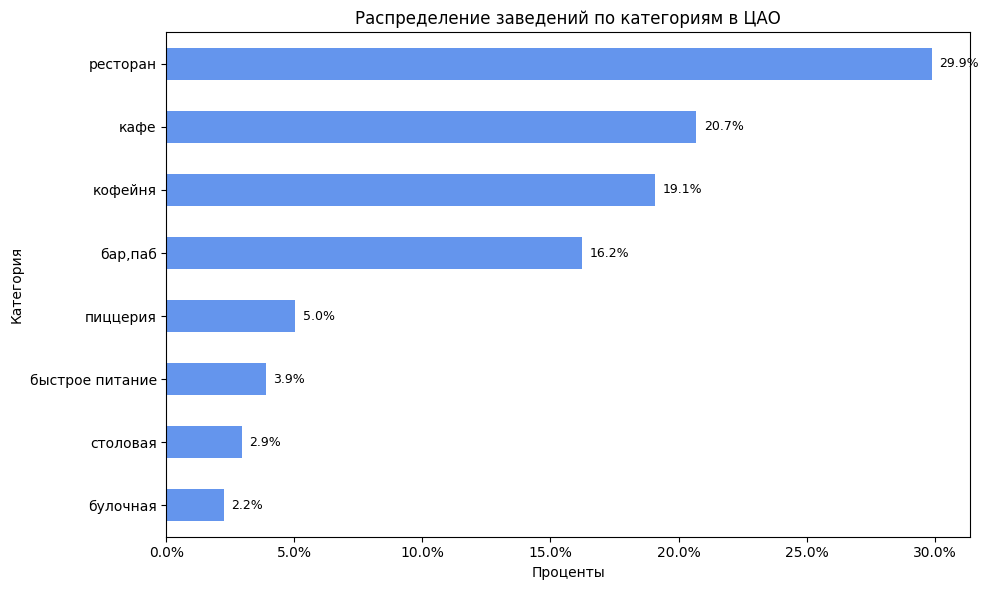

In [135]:
# Распределение в ЦАО по заведениям
central_district_data = df[df['district'] == 'центральный_административный_округ']
district_share = central_district_data['category'].value_counts(normalize=True).sort_values()
ax = district_share.plot(
    kind='barh', figsize=(10, 6), color='cornflowerblue'
)

ax.set_ylabel('Категория')          
ax.set_xlabel('Проценты')   
ax.set_title('Распределение заведений по категориям в ЦАО')

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))

for i, v in enumerate(district_share.values):
    ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Анализ:
- количество ресторанов лидирует с большим отрывом: около 30%
- по сравнению с данными по всем районам, есть небольшие отличия в распределении: 
    - доля ресторанов тут больше, чем кафе 
    - доля баров, пабов выше - 16.2% по сравнению с общими данными - 9.1%;
    - можно выделить малочисленные категории (пиццерии, быстрое питание, столовые и булочные - менее 5% каждая категория)

---

### Изучение соотношения сетевых и несетевых заведений 

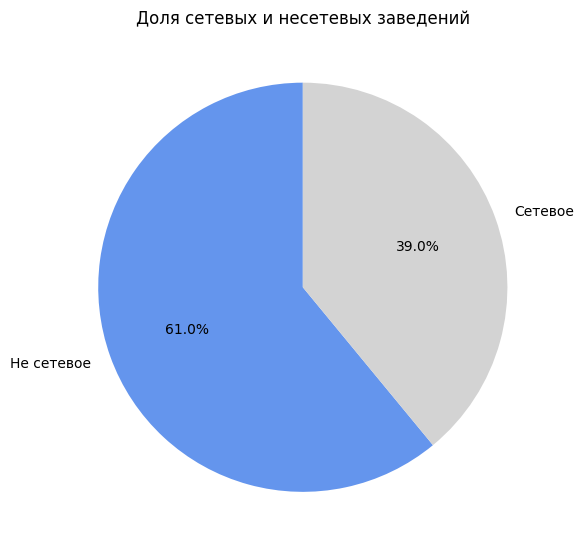

In [136]:
# изучение сетевых/несетевых заведений
chain_share = (
    central_district_data['chain']
    .value_counts(normalize=True)
    .rename({True: 'Сетевое', False: 'Не сетевое'})
)

ax = chain_share.plot(
    kind='pie',
    figsize=(6, 6),
    autopct='%1.1f%%', 
    startangle=90,
    colors=['cornflowerblue', 'lightgray']
)

ax.set_ylabel('')
ax.set_title('Доля сетевых и несетевых заведений')
plt.tight_layout()
plt.show()

### Анализ:
- в целом количество не сетевых 61% значительно больше сетевых 39%

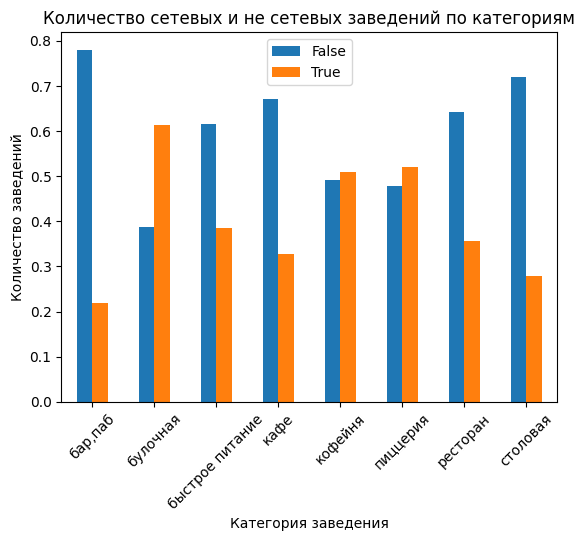

In [137]:
# соотношение сетевых/не сетевых в разрезе каждой группы
df_chain_unstack = df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0)

df_chain_unstack.plot(kind='bar')


plt.title('Количество сетевых и не сетевых заведений по категориям') 
plt.ylabel('Количество заведений') 
plt.xlabel('Категория заведения') 
plt.xticks(rotation=45)  
plt.legend()  

# Отображаем график
plt.show()

In [138]:
df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0) * 100

chain,False,True
category,,
"бар,паб",78.010471,21.989529
булочная,38.671875,61.328125
быстрое питание,61.525705,38.474295
кафе,67.213805,32.786195
кофейня,49.079320,50.920680
пиццерия,47.867299,52.132701
ресторан,64.299706,35.700294
столовая,72.063492,27.936508


### Анализ:
- **сетевые** заведения чаще встречаются в категориях:
    - булочная: 61%
    - кофейня: 50.9%
    - пиццерия: 52.1%
- в остальных категориях чаще встречаются **не сетевые**:
    - бар,паб:	78%
    - быстрое питание:	61%
    - кафе:	67%
    - ресторан:	64%
    - столовая:	72%

---

### Исследование количества посадочных мест в заведениях. 

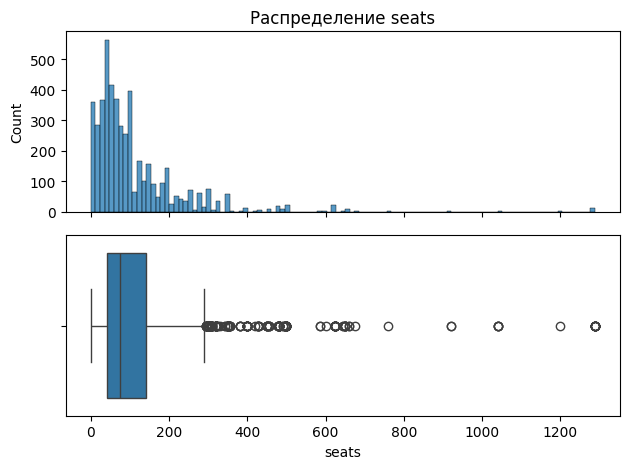

In [139]:
fig, axes = plt.subplots(2, 1, sharex=True)

sns.histplot(data=df, x='seats', ax=axes[0])
axes[0].set_title('Распределение seats')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='seats', ax=axes[1])
axes[1].set_xlabel('seats')

plt.tight_layout()
plt.show()

In [140]:
quantile = 0.95
extra_seats_bound = df['seats'].quantile(quantile)
print(f'{quantile * 100} % заведений имеют менее {extra_seats_bound} посадочных мест')

95.0 % заведений имеют менее 307.0 посадочных мест


In [141]:
df['seats'].describe()

count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

### Анализ:
- медианное значение количества мест в заведениях: 75
- данные содержат выбросы. 
- имеются малочисленные заведения (менее 5% от общего числа) с количеством мест более 307 и до 1288

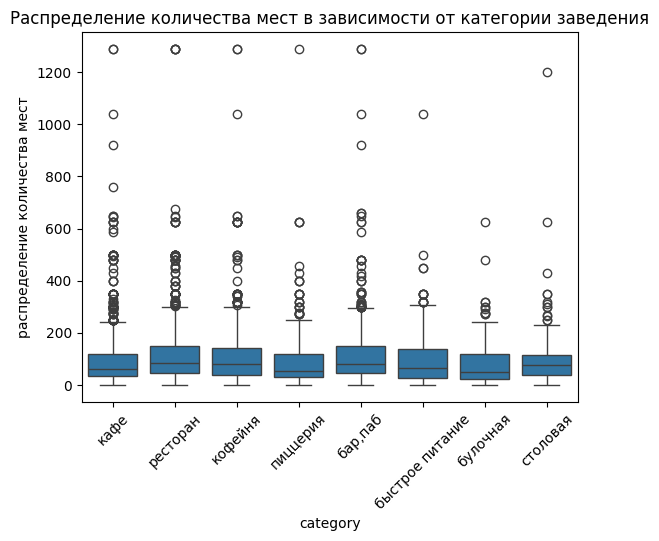

In [142]:
# смотрим на распределения по местам в разрезе категорий
sns.boxplot(data=df, y='seats', x='category')
plt.xticks(rotation=45) 
plt.title('Распределение количества мест в зависимости от категории заведения')
plt.ylabel('распределение количества мест')
plt.show()

In [143]:
# выбросы по каждой категории 
p90_by_cat = (
    df
    .groupby('category')['seats']
    .quantile(0.90)
    .rename('p90')
)

df_out = df.merge(p90_by_cat, on='category', how='left')
df_out['is_outlier_90'] = df_out['seats'] > df_out['p90']


outliers = df_out[df_out['is_outlier_90']].copy()
no_outliers = df_out[~df_out['is_outlier_90']].copy()


In [144]:
# наиболее часто встречающиеся выбросы по категориям
most_freq_with_count = (
    outliers.groupby('category')['seats']
    .apply(lambda s: s.value_counts().head(1))
    .rename('count')
    .reset_index()
    .rename(columns={'level_1': 'seats'})
)

most_freq_with_count

,category,seats,count
0,"бар,паб",300.0,9
1,булочная,273.0,2
2,быстрое питание,273.0,6
3,кафе,250.0,21
4,кофейня,300.0,13
5,пиццерия,350.0,5
6,ресторан,350.0,17
7,столовая,250.0,2


### Анализ:
По распределению выбросов в каждой категории можно сделать предположения о их природе:
- выбросы могут быть связвано с наличием банкетных помещений, открытых фудкортов 
- наиболее часто встречающиеся выбросы в каждой категории имеют значения 250, 300, 320, 350 - это похоже на стандартную максимальную вместимость, которую указывают для заведений в открытых источниках. Скорее всего, это не реальное количество посадочных мест, а стандартное значение количества людей, которые гипотетически можно в это заведение привести и всем хватит места (не обязательно сидя).


In [145]:
# наиболее типичное количество посадочных мест по категориям (отсеяли выбросы)
no_outliers.groupby('category')['seats'].median()

category
бар,паб            75.0
булочная           48.0
быстрое питание    55.0
кафе               50.0
кофейня            65.0
пиццерия           49.0
ресторан           80.0
столовая           60.0
Name: seats, dtype: float32

---

### Исследование рейтинга заведений.

In [146]:
df['rating'].describe()

count    8401.000000
mean        4.230258
std         0.469826
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [147]:
avg_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)

In [148]:
# средний рейтинг по каждой категории
avg_rating

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290401
кофейня            4.278754
булочная           4.268359
столовая           4.211429
кафе               4.124284
быстрое питание    4.050249
Name: rating, dtype: float32

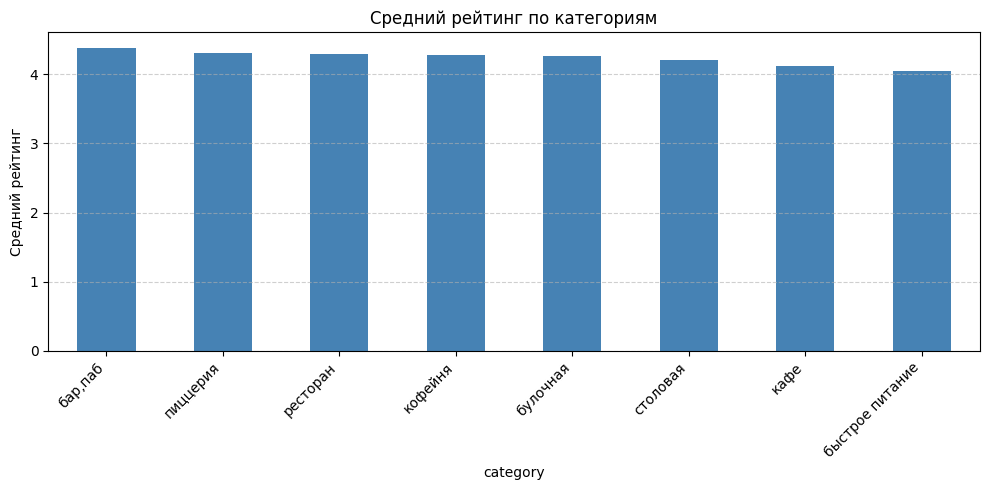

In [149]:
ax = avg_rating.plot(kind='bar', figsize=(10, 5), color='steelblue')
ax.set_xlabel('category')
ax.set_ylabel('Средний рейтинг')
ax.set_title('Средний рейтинг по категориям')
ax.grid(axis='y', linestyle='--', alpha=0.6)  # горизонтальные линии сетки
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [150]:
print('Относительный размах по среднему рейтингу (%):')
(avg_rating.max() - avg_rating.min()) / avg_rating.max() * 100

Относительный размах по среднему рейтингу (%):


np.float32(7.69077)

### Анализ
- средний рейтинг мало отличается от вида заведения общепита. Размах по значениям 7.6%

---

### Корреляционный анализ. Связь с рейтингом заведения.

In [151]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,москва_улица_дыбенко_71,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,False,NaN,NaN,NaN,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре_комнаты,ресторан,москва_улица_дыбенко_36_корп_1,северный_административный_округ,"ежедневно, 10:00–22:00",4.5,False,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,москва_клязьминская_улица_15,северный_административный_округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,False,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse_coffee_shop,кофейня,москва_улица_маршала_федоренко_12,северный_административный_округ,"ежедневно, 09:00–22:00",5.0,False,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль_марко,пиццерия,москва_правобережная_улица_1б,северный_административный_округ,"ежедневно, 10:00–22:00",5.0,True,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False


In [152]:
# какие колонки будем изучать в рамках корреляционного анализа
numeric_columns = [
    'rating',
    'seats',
    'middle_avg_bill',
    'middle_coffee_cup'
]

categorial_columns = ['chain', 'district', 'is_24_7', 'category', 'price']

In [153]:
df_rating_corr_analysis = df[numeric_columns + categorial_columns]

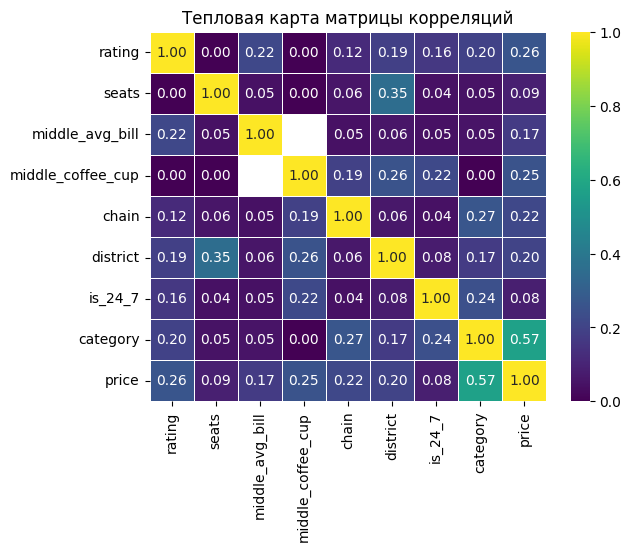

Корреляция переменных с 'rating':
rating               1.000000
price                0.262056
middle_avg_bill      0.218416
category             0.199065
district             0.189582
is_24_7              0.161354
chain                0.118926
seats                0.000000
middle_coffee_cup    0.000000
Name: rating, dtype: float64


In [154]:
# Посчитаем матрицу корреляций
corr_matrix = df_rating_corr_analysis.phik_matrix(interval_cols=numeric_columns)

# Создаём тепловую  карту
sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

# Показываем график с заголовком
plt.title('Тепловая карта матрицы корреляций')
plt.show()
print("Корреляция переменных с 'rating':")
print(corr_matrix['rating'].sort_values( ascending=False))

Самая сильная положительная связь рейтинга с :
- категорией цены: корреляция 0.26

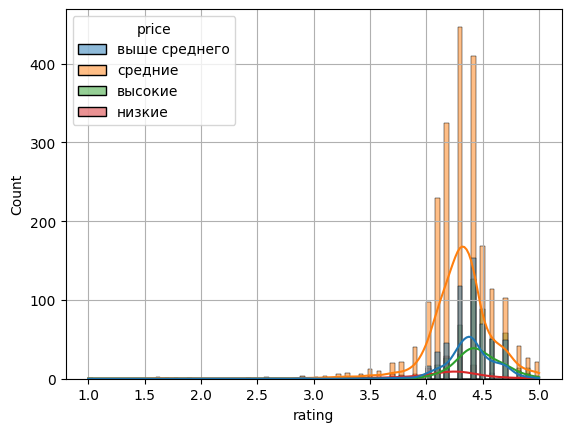

In [155]:
sns.histplot(data=df_rating_corr_analysis, x='rating', hue='price', kde=True)
plt.grid()

plt.show() 

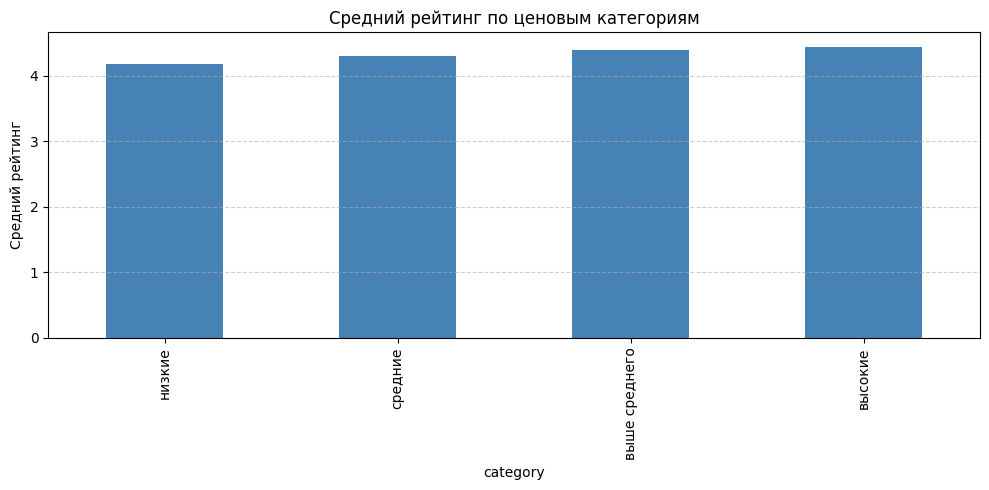

In [156]:
avg_rating = df_rating_corr_analysis.groupby('price')['rating'].mean().sort_values(ascending=True)

ax = avg_rating.plot(kind='bar', figsize=(10, 5), color='steelblue')
ax.set_xlabel('category')
ax.set_ylabel('Средний рейтинг')
ax.set_title('Средний рейтинг по ценовым категориям')
ax.grid(axis='y', linestyle='--', alpha=0.6)  # горизонтальные линии сетки
plt.tight_layout()
plt.show()

In [157]:
avg_rating

price
низкие           4.173077
средние          4.297874
выше среднего    4.386347
высокие          4.436611
Name: rating, dtype: float32

In [158]:
print('Размах в процентах: ')
(avg_rating.max() - avg_rating.min()) / avg_rating.max() * 100

Размах в процентах: 


np.float32(5.9399757)

### Анализ:
- с увеличением ценового сегмента средний рейтинг имеет тенденцию расти. Но эта связь незначительная: коэффициент корреляции 0.26
- разброс среднего рейтинга по ценовым сегментам: около 5.93%

---

### Исследование самых популярных заведений Москвы


In [159]:
top15_chains = (
    df[df['chain']]
    .groupby('name', as_index=False)
    .agg(
        category=('category','first'),
        establishments=('id', 'count'),
        mean_rating=('rating', 'mean')
    )
    .sort_values('establishments', ascending=False)
    .head(15)
)

top15_chains


,name,category,establishments,mean_rating
725,шоколадница,кофейня,120,4.177500
335,доминос_пицца,пиццерия,76,4.169737
331,додо_пицца,пиццерия,74,4.286487
146,one_price_coffee,кофейня,71,4.064789
738,яндекс_лавка,ресторан,69,3.872464
58,cofix,кофейня,65,4.075385
168,prime,ресторан,50,4.116000
662,хинкальная,быстрое питание,44,4.322727
408,кофепорт,кофейня,42,4.147619
417,кулинарная_лавка_братьев_караваевых,кафе,39,4.394872


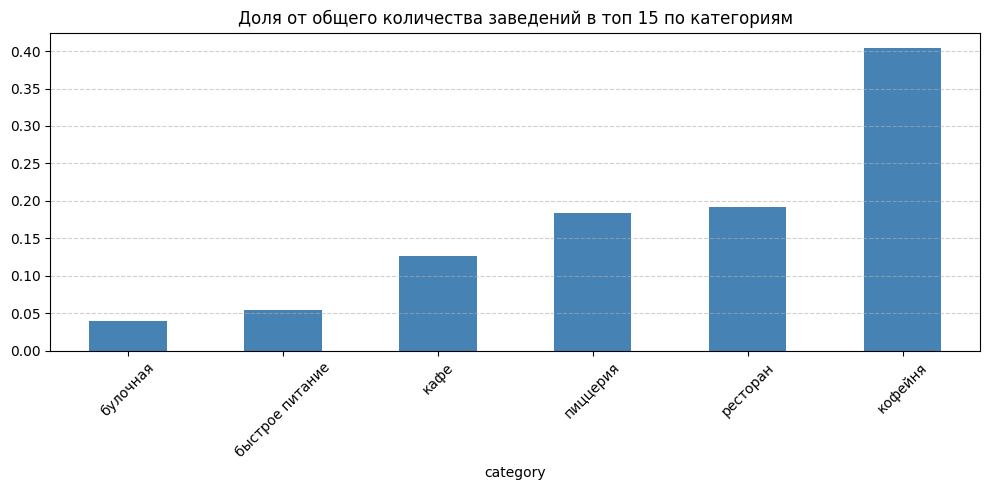

In [160]:
top15_chains_show = top15_chains.groupby('category')['establishments'].sum().sort_values() / top15_chains['establishments'].sum()
ax = top15_chains_show.plot(kind='bar', figsize=(10, 5), color='steelblue')
ax.grid(axis='y', linestyle='--', alpha=0.6)  # горизонтальные линии сетки
plt.xticks(rotation=45)
plt.title('Доля от общего количества заведений в топ 15 по категориям')
plt.tight_layout()
plt.show()

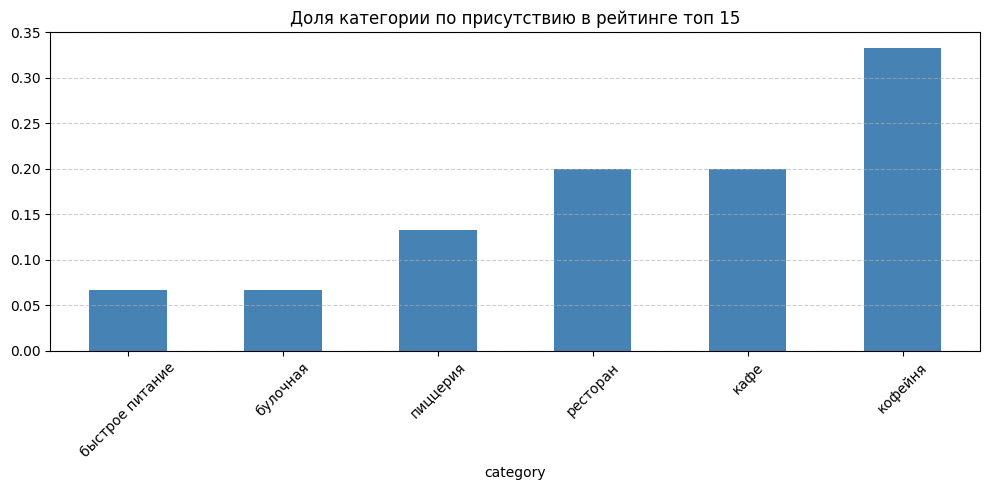

In [161]:
top15_chains_show = top15_chains['category'].value_counts(normalize=True).sort_values()
ax = top15_chains_show.plot(kind='bar', figsize=(10, 5), color='steelblue')
ax.grid(axis='y', linestyle='--', alpha=0.6)  # горизонтальные линии сетки
plt.xticks(rotation=45)
plt.title('Доля категории по присутствию в рейтинге топ 15')
plt.tight_layout()
plt.show()

In [162]:
top15_chains_show = top15_chains.groupby('category')['mean_rating'].mean().sort_values()
top15_chains_show

category
ресторан           4.037383
кофейня            4.089933
кафе               4.182942
пиццерия           4.228112
быстрое питание    4.322727
булочная           4.396875
Name: mean_rating, dtype: float32

### Анализ:
Особенности самых популярных сетей:
- самое большое количество заведений среди кофеен
- присутствие в топ 15 больше всего у кофеен
- средний рейтинг среди популярных заведний высокий: более 4 
- в среднем рейтинг у популярных сетевых булочных выше, чем у других видов заведений. 
- разброс о среднему рейтингу среди популярных категорий сетей небольшой: 4.0-4.4 баллов (10%)

---

### Исследование среднего чека заведений


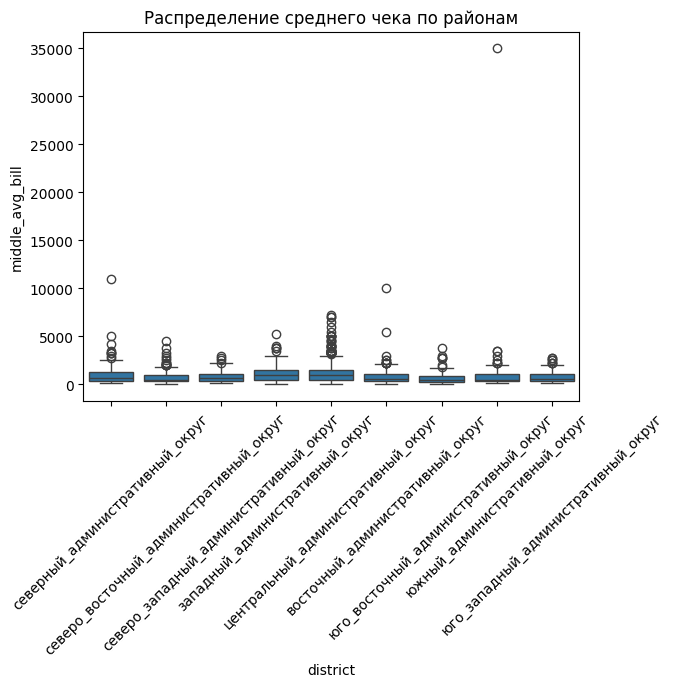

In [163]:
# посмотрим на распеределение по районам
sns.boxplot(data=df, y='middle_avg_bill', x='district')
plt.xticks(rotation=45) 
plt.title('Распределение среднего чека по районам')
plt.show()

Имеются выбросы. В качестве статистики выберем медиану, чтобы избежать искажений от выбросов

In [164]:
df.groupby('district')['middle_avg_bill'].median()


district
восточный_административный_округ            575.0
западный_административный_округ            1000.0
северный_административный_округ             650.0
северо_восточный_административный_округ     500.0
северо_западный_административный_округ      700.0
центральный_административный_округ         1000.0
юго_восточный_административный_округ        450.0
юго_западный_административный_округ         600.0
южный_административный_округ                500.0
Name: middle_avg_bill, dtype: float32

In [165]:

def plot_heat_map_geo_grid(value: pd.Series, value_name: str, fmt: str='.0f'):
    geo_grid = pd.DataFrame(
        index=['Север', 'Центр', 'Юг'],
        columns=['Запад', 'Центр', 'Восток'],
        data=np.nan
    )

    geo_grid.loc['Север', 'Запад']   = value.get('северо_западный_административный_округ')
    geo_grid.loc['Север', 'Центр'] = value.get('северный_административный_округ')
    geo_grid.loc['Север', 'Восток']  = value.get('северо_восточный_административный_округ')

    geo_grid.loc['Центр', 'Запад']   = value.get('западный_административный_округ')
    geo_grid.loc['Центр', 'Центр'] = value.get('центральный_административный_округ')
    geo_grid.loc['Центр', 'Восток']  = value.get('восточный_административный_округ')

    geo_grid.loc['Юг', 'Запад']      = value.get('юго_западный_административный_округ')
    geo_grid.loc['Юг', 'Центр']    = value.get('южный_административный_округ')
    geo_grid.loc['Юг', 'Восток']     = value.get('юго_восточный_административный_округ')

    plt.figure(figsize=(8, 5))
    sns.heatmap(
        geo_grid,
        annot=True,
        fmt=fmt,
        cmap='YlOrRd',
        linewidths=1,
        linecolor='white',
        cbar_kws={'label': value_name}
    )
    plt.title('Тепловая карта по географии округов Москвы')
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()


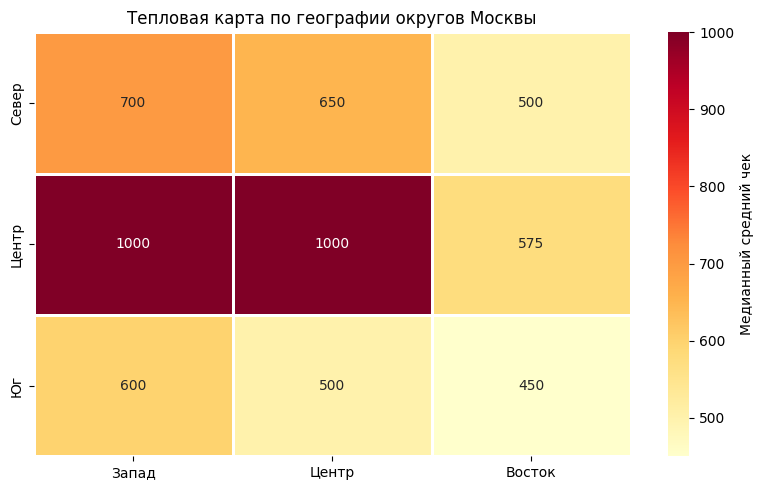

In [166]:
# медианный средний чек по округам
bill = df.groupby('district')['middle_avg_bill'].median()
plot_heat_map_geo_grid(value=bill, value_name='Медианный средний чек')

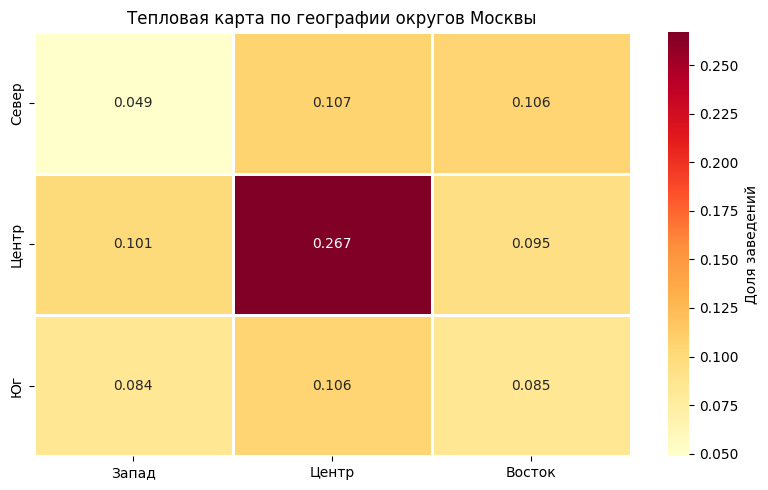

In [167]:
count_in_district = df['district'].value_counts(normalize=True)

plot_heat_map_geo_grid(value=count_in_district, value_name='Доля заведений', fmt='.3f')

---


### Анализ:
- в центре медианный чек выше, чем на окраине 
- также можно отметить, что на западе и северо-западе  более высокий чек, нежели на востоке и юго востоке
- центр крайне насыщен заведениями (не менее чем в 3 раза большепо сравнению любом другим округом)
- меньше всего конкурентов на северо-западе и юго-востоке 

---

### Промежуточный вывод

- В центральном районе точек общественного питания больше всего: около 33.5%. При этом в других районах точек общепита менее 11%.

- по категориям заведений лидируют кафе (28%) и рестораны (24.3%), далее идут кофейни (16.8%). К малочисленным сегментам можно отнести бары/пабы, быстрое питание, столовые и булочные (менее 9% у каждой категории)

- рынок преимущественно не сетевой (61%). При этом среди пиццерий, кофеен, булочных сетевых точек больше.

- медианное значение вместительности заведения около 78. В данных по вместительности присутствуют выбросы по каждой категории. Самые встречающиеся значение выбросов около 300 - технические, стандартные цифры по гипотетической вместимости заведения, а не реальное количество мест в заведении. Выбросы на 500+ можно объяснить фудкортами/банкетными залами.

- у рейтинга имеется слабая положительная связь с ценовым сегментом. Уровень корреляции 0.26; То есть с повышением ценового сегмента рейтинг имеет тенденцию расти, но несущественно.

- медианный чек высокий в центре. На западе/севоро-западе выше чем на востоке и юго-востоке

- в топовых по популярности сетях стабильно высокий рейтинг: медианное значение в каждой категории от 4.0 до 4.4

- среди популярных сети: кофейни




## 4. Итоговый вывод и рекомендации

1. В настоящей работе проведен анализ данных о заведениях общественного питания в городе Москве. Проделанная работа состояла из нескольких этапов:
    1) Выгрузка данных, проверка на соответствие заявленному описанию
    2) Предварительная обработка и приведение к формату, удобному для исследований.
    3) Проведение исследовательского анализа

2. По результатам ознакомления с данными и их предварительной обработки расхождений с заявленным описанием не выявлено, данные приведены к удобному для анализа формату с минимальными потерями (менее 0.06%). По результатам последующего анализа данных можно сформулировать ключевые выводы:
    - больше всего точек общественного питания в центре: 33.5%
    - топ 3 категории: кафе: 28.3%, рестораны: 24.3%, кофейни 16.8%
    - рынок преимущественно не сетевой: 61%. Однако для пиццерий, кофеен, булочных сетевых точек больше
    - характерное значение по вместимости заведений: медиана - 78 мест
    - выбросы по значениям вместимости (300+ мест) - формальные официальные цифры открытых источников, не отражающие реальное количество посадочных мест в заведениях
    - рейтинг слабо зависит от ценового сегмента. Корреляция по с этим признаком на уровне 0.26. 
    - в центральном районе медианный чек выше, чем на окраинах. Медианный чек на западе и северо-западе выше, чем на востоке и юго-востоке Москвы
    - самыми популярными по количеству точек являются кофейни 
    - рейтинг популярных заведений стабильно высокий: медианное знаяение оценок среди популярных сетей 4.0+

3. Рекомендации
    - Для обеспечения более высокого чека заведению стоит рассмотреть открытие в центре, на западе/северо-западе. 
    - При этом конкуренция в центре крайне высокая по сравнению с другими районами. Чтобы избежать большой конкуренции рекомендуется рассмотреть северо-западый и юго-восточный районы города. 
    - По формату заведения лучше избегать самых популярных ниш в выбранном районе, чтобы уменьшить влияние конкурентов. Стоит избегать открытия ресторанов и кафе в центре, поскольку рынок перенасыщен ими.
    - по вместимости заведения стоит ориентироваться на медианное значение в категории
    - рейтинг заведений не связан с его категорией, ценовым сегментом или районом. 
    - для запуска пиццерий, кофеен, булочных лучше выбрать сетевой формат, поскольку они статистически лучше приживаются на рынке. В остальных случаях можно смело выбирать не сетевой формат.
